In [ ]:
from pathlib import Path

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
import xarray as xr
from context_flux_no.models.multiphysics import (
    AbstractMultiphysicsOperator,
    DISCO,
    DPOT,
)
from context_flux_no.training import PDEDataset
from context_flux_no.training.loader import SegmentLoader
from jaxtyping import Array, Float, PRNGKeyArray

In [2]:
# jax.config.update("jax_enable_x64", True)
jax.config.update("jax_default_device", jax.devices("gpu")[3])
datadir = Path("../../data")
# dataset_xr = xr.load_dataset(
#     datadir / "cubic_no_source_large_train.hdf5", engine="h5netcdf"
# )
dataset_xr = xr.open_mfdataset(
    sorted(list(datadir.glob("cubic_no_source_large_train_seed=*.hdf5"))),
    combine="nested",
    concat_dim="pde",
    engine="h5netcdf",
).isel(t=slice(None, None, 10))
dataset_xr

<xarray.Dataset> Size: 8GB
Dimensions:  (pde: 1000, ic: 100, t: 101, dim: 1, x: 100, param: 3)
Coordinates:
  * t        (t) float64 808B 0.0 0.005 0.01 0.015 0.02 ... 0.485 0.49 0.495 0.5
  * x        (x) float64 800B 0.005 0.015 0.025 0.035 ... 0.975 0.985 0.995
  * dim      (dim) <U1 4B 'u'
  * param    (param) <U1 12B 'a' 'b' 'c'
Dimensions without coordinates: pde, ic
Data variables:
    values   (pde, ic, t, dim, x) float64 8GB dask.array<chunksize=(100, 100, 101, 1, 100), meta=np.ndarray>
    coeffs   (pde, param) float64 24kB dask.array<chunksize=(100, 3), meta=np.ndarray>

In [3]:
dataset_train, dataset_test = PDEDataset.from_xarray(dataset_xr).split_by_time(80)

/home/jhko725/projects/CONTEXT_FLUX_NO/src/context_flux_no/training/dataset.py:33: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return cls(u, t, x, coeffs, dim_names, coeff_names)
/home/jhko725/.local/share/uv/python/cpython-3.12.11-linux-x86_64-gnu/lib/python3.12/dataclasses.py:1588: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return obj.__class__(**changes)


In [4]:
dataset_train

PDEDataset(
  u=f64[1000,100,80,1,100](numpy),
  t=f64[80](numpy),
  x=f64[100](numpy),
  coeffs=f64[1000,3](numpy),
  dim_names=[np.str_('u')],
  coeff_names=[np.str_('a'), np.str_('b'), np.str_('c')]
)

In [5]:
loader = SegmentLoader(dataset_train, segment_length=21, batch_size=1024)
batch, _ = loader.load_batch(loader.init())

In [ ]:
batch[0].shape

(1024, 21, 1, 100)

In [ ]:
16000000

In [12]:
dpot = DPOT(
    num_spatial_dims=1,
    in_channels=1,
    out_channels=1,
    in_timesteps=20,
    patch_size=(4,),
    img_size=(100,),
    embedding_dim=256,
    max_frequency_modes=(10,),
    fno_depth=5,
    num_blocks=4,
    num_classes=12,
    hidden_dim_patch=256,
    hidden_dim_fno=256,
    hidden_dim_output=32,
    key=jax.random.key(0),
)
dpot.num_parameters()  # 0.238M

2383469

In [6]:
disco = DISCO(
    num_spatial_dims=1,
    channels=1,
    embedding_dim=48,
    patch_size=100,
    num_hypernet_blocks=2,
    droppath=0.1,
    num_hypernet_heads=2,
    mlp_hidden_dim=48,
    boundary_condition="periodic",
    key=jax.random.key(0),
)
disco.num_parameters()  # 11.67M

8067638

In [13]:
def loss_fn(
    model: AbstractMultiphysicsOperator,
    batch: tuple[Float[Array, "..."], ...],
    key: PRNGKeyArray,
) -> tuple[Float[Array, ""], dict]:
    u, dt, dx = batch
    u0, u1 = u[:, :-1], u[:, -1]
    keys = jax.random.split(key, u0.shape[0])
    u1_pred = eqx.filter_vmap(lambda u_, key_: model(u_, key=key_))(u0, keys)[0]
    return jnp.mean((u1 - u1_pred) ** 2), dict()


In [14]:
eqx.filter_value_and_grad(loss_fn, has_aux=True)(dpot, batch, jax.random.key(0))

2026-02-27 18:41:13.322479: E external/xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-27 18:41:13.450758: E external/xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-27 18:41:23.164533: E external/xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng0{} for conv %cudnn-conv-bw-filter.1 = (f32[256,1,256]{2,1,0}, u8[0]{0}) custom-call(%transpose, %transpose.1), window={size=1}, dim_labels=b0f_o0i->b0f, custom_call_target="__cudnn$convBackwardFilter", metadata={op_name="jit(conv_general_dilated)/jit(main)/conv_general_dilated" source_file="/home/jhko725/projects/CONTEXT_FLUX_NO/.venv/lib/python3.12/site-packages/equinox/nn/_conv.py" source_line=238}, backend_config={"operation_queue_

((Array(0.74840635, dtype=float32), {}),
 DPOT(
   patch_embedding=PatchEmbedding(
     layers=(
       Conv(
         num_spatial_dims=1,
         weight=f32[256,2,4],
         bias=f32[256,1],
         in_channels=2,
         out_channels=256,
         kernel_size=(4,),
         stride=(4,),
         padding=((0, 0),),
         dilation=(1,),
         groups=1,
         use_bias=True,
         padding_mode='ZEROS'
       ),
       Conv(
         num_spatial_dims=1,
         weight=f32[256,256,1],
         bias=f32[256,1],
         in_channels=256,
         out_channels=256,
         kernel_size=(1,),
         stride=(1,),
         padding=((0, 0),),
         dilation=(1,),
         groups=1,
         use_bias=True,
         padding_mode='ZEROS'
       )
     ),
     num_spatial_dims=1,
     patch_size=(4,),
     in_dim=2,
     embedding_dim=256,
     activation=<function gelu>,
     final_activation=<function PatchEmbedding.<lambda>>
   ),
   position_embedding=LearnedPositionEncodin

In [15]:
def train(
    model: AbstractMultiphysicsOperator,
    dataloader: SegmentLoader,
    optimizer: optax.GradientTransformation,
    loss_fn,
    max_steps: int,
    *,
    key: PRNGKeyArray = jax.random.key(0),
):
    loss_grad_fn = eqx.filter_value_and_grad(loss_fn, has_aux=True)

    @eqx.filter_jit
    def train_step(model_, loader_state_, opt_state_, key_):
        batch, loader_state_next = dataloader.load_batch(loader_state_)
        key_, key_next = jax.random.split(key_)

        (loss, aux), grads = loss_grad_fn(model_, batch, key_)
        updates, opt_state_next = optimizer.update(
            grads, opt_state_, eqx.filter(model_, eqx.is_array)
        )
        model_ = eqx.apply_updates(model_, updates)
        return loss, aux, model_, loader_state_next, opt_state_next, key_next

    loader_state = dataloader.init()
    opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

    loss_history = []
    # try:
    for i in range(max_steps):
        loss, aux, model, loader_state, opt_state, key = train_step(
            model, loader_state, opt_state, key
        )

        loss_scalar = loss.item()
        print(f"Step: {i}: loss = {loss_scalar}")
        loss_history.append(loss_scalar)
    # finally:
    return model, jnp.asarray(loss_history)

In [16]:
optimizer = optax.adamw(1e-3)
model, loss_history = train(dpot, loader, optimizer, loss_fn, max_steps=5000)

/home/jhko725/projects/CONTEXT_FLUX_NO/.venv/lib/python3.12/site-packages/jax/_src/interpreters/mlir.py:1132: UserWarning: A large amount of constants were captured during lowering (6.40GB total). If this is intentional, disable this warning by setting JAX_CAPTURED_CONSTANTS_WARN_BYTES=-1. To obtain a report of where these constants were encountered, set JAX_CAPTURED_CONSTANTS_REPORT_FRAMES=-1.
  warnings.warn(message)


Step: 0: loss = 0.7484062910079956
Step: 1: loss = 0.6433678865432739
Step: 2: loss = 0.4840461313724518
Step: 3: loss = 0.357277512550354
Step: 4: loss = 0.2425502985715866
Step: 5: loss = 0.14366579055786133
Step: 6: loss = 0.23443222045898438
Step: 7: loss = 0.1875021904706955
Step: 8: loss = 0.09491460770368576
Step: 9: loss = 0.09339765459299088
Step: 10: loss = 0.11667086184024811
Step: 11: loss = 0.1118546649813652
Step: 12: loss = 0.09430375695228577
Step: 13: loss = 0.07342973351478577
Step: 14: loss = 0.06972458958625793
Step: 15: loss = 0.0837879553437233
Step: 16: loss = 0.08499925583600998
Step: 17: loss = 0.06937099248170853
Step: 18: loss = 0.05497037246823311
Step: 19: loss = 0.05745035037398338
Step: 20: loss = 0.06130700930953026
Step: 21: loss = 0.06295374035835266
Step: 22: loss = 0.05598115175962448
Step: 23: loss = 0.046395424753427505
Step: 24: loss = 0.04656084254384041
Step: 25: loss = 0.04706341773271561
Step: 26: loss = 0.04831058531999588
Step: 27: loss = 0.

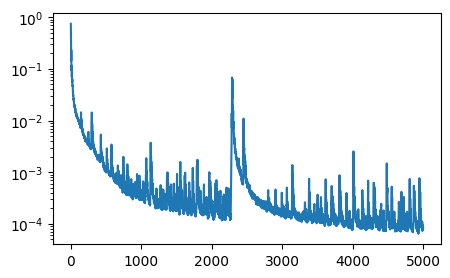

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.plot(loss_history)
ax.set_yscale("log")